# Gridding methods

## ArgoPy dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from haversine import Unit, haversine, haversine_vector
from argopy import DataFetcher 
from datetime import timedelta
from pathlib import Path
import xarray as xr
from anemoi.datasets import open_dataset
import cartopy.crs as ccrs

In [2]:
north, west, south, east = 90, -180, 0, 180

# Fetch real data once for the whole period
fetcher1 = DataFetcher().region([west, east, south, north, 0, 50, "2024-01-01", "2024-01-02"])
df1 = fetcher1.to_dataframe()
fetcher2 = DataFetcher().region([west, east, south, north, 0, 50, "2024-01-02", "2024-01-03"])
df2 = fetcher2.to_dataframe()
df = pd.concat([df1, df2], ignore_index=True)

In [3]:
df['DATE'] = df['TIME'].dt.strftime("%Y-%m-%d")
df

,CYCLE_NUMBER,DATA_MODE,DIRECTION,PLATFORM_NUMBER,POSITION_QC,PRES,PRES_ERROR,PRES_QC,PSAL,PSAL_ERROR,PSAL_QC,TEMP,TEMP_ERROR,TEMP_QC,TIME_QC,LATITUDE,LONGITUDE,TIME,DATE
0,5,A,A,5906993,1,7.100000,2.003,1,37.953999,0.004,1,17.576000,0.002,1,1,36.921558,18.041198,2024-01-01 00:02:00,2024-01-01
1,5,A,A,5906993,1,9.100000,2.004,1,37.958000,0.004,1,17.584000,0.002,1,1,36.921558,18.041198,2024-01-01 00:02:00,2024-01-01
2,5,A,A,5906993,1,11.000000,2.005,1,37.964001,0.004,1,17.597000,0.002,1,1,36.921558,18.041198,2024-01-01 00:02:00,2024-01-01
3,5,A,A,5906993,1,12.800000,2.005,1,37.958000,0.004,1,17.608999,0.002,1,1,36.921558,18.041198,2024-01-01 00:02:00,2024-01-01
4,5,A,A,5906993,1,15.000000,2.006,1,37.977001,0.004,1,17.632000,0.002,1,1,36.921558,18.041198,2024-01-01 00:02:00,2024-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10715,10,D,A,2902891,1,8.900000,2.004,1,33.834202,0.004,1,29.014999,0.002,1,1,11.214596,129.472256,2024-01-02 23:40:58,2024-01-02
10716,10,D,A,2902891,1,18.100000,2.008,1,33.836201,0.004,1,29.018000,0.002,1,1,11.214596,129.472256,2024-01-02 23:40:58,2024-01-02
10717,10,D,A,2902891,1,28.700001,2.012,1,33.858200,0.004,1,29.035999,0.002,1,1,11.214596,129.472256,2024-01-02 23:40:58,2024-01-02
10718,10,D,A,2902891,1,38.900002,2.016,1,33.918201,0.004,1,29.080000,0.002,1,1,11.214596,129.472256,2024-01-02 23:40:58,2024-01-02


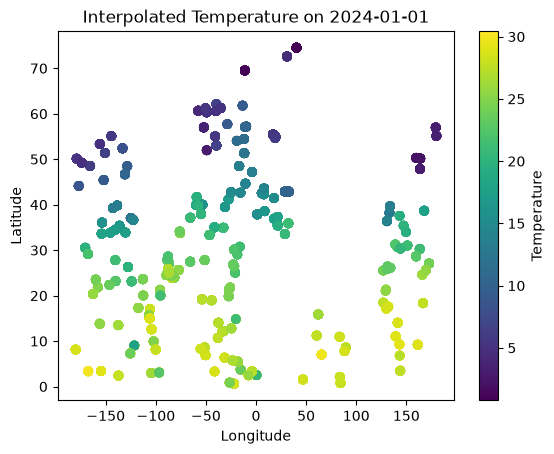

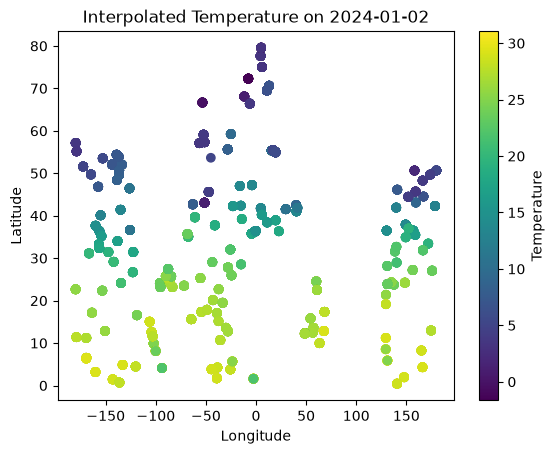

In [4]:
# plot this data to check it looks reasonable
for t_idx, date in enumerate(df['DATE'].unique()):
    tmp_df = df[df['DATE'] == date]
    plt.figure()
    plt.scatter(tmp_df['LONGITUDE'], tmp_df['LATITUDE'], c=tmp_df['TEMP'], cmap='viridis')
    plt.colorbar(label='Temperature')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(f'Interpolated Temperature on {date}')

    

In [5]:
# Grid setup
lats = np.arange(south + 0.5, north + 0.5, 2)
lons = np.arange(west + 0.5, east + 0.5, 2)
n_lat = len(lats)
n_lon = len(lons)
lat_grid, lon_grid = np.meshgrid(lats, lons, indexing="ij")
grid_points = np.column_stack((lat_grid.ravel(), lon_grid.ravel()))
times = pd.to_datetime(["2024-01-01", "2024-01-02"]).to_pydatetime().tolist()
temp_data = np.full((len(times), len(lats), len(lons)), np.nan, dtype=float)


### Nested loop

In [6]:
for t_idx, date in enumerate(times):
    sigma = 200
    
    tmp_df = df[df['DATE'] == date.strftime("%Y-%m-%d")]

    for lat_idx, lat in enumerate(lats):
        for lon_idx, lon in enumerate(lons):
            t_weighted, sum_weights = 0, 0
            for row in tmp_df.itertuples():
                
                obs_lat = row.LATITUDE
                obs_lon = row.LONGITUDE
                obs_temp = row.TEMP

                obs_point = (obs_lat, obs_lon)  # shape: (n_obs, 2)
                grid_point = (lat, lon)  # shape: (n_lat*n_lon, 2)
                
                # Pairwise distances in km: shape (n_obs, n_lat*n_lon)
                distance_km = haversine(
                    obs_point,
                    grid_point,
                    unit=Unit.KILOMETERS,
                    )
                distance2 = distance_km ** 2# calculate the weighted distance
                weight = np.exp(-0.5 * distance2 / sigma**2)
                t_weighted += weight * row.TEMP
                sum_weights += weight
            temp_data[t_idx, lat_idx, lon_idx] = t_weighted / sum_weights

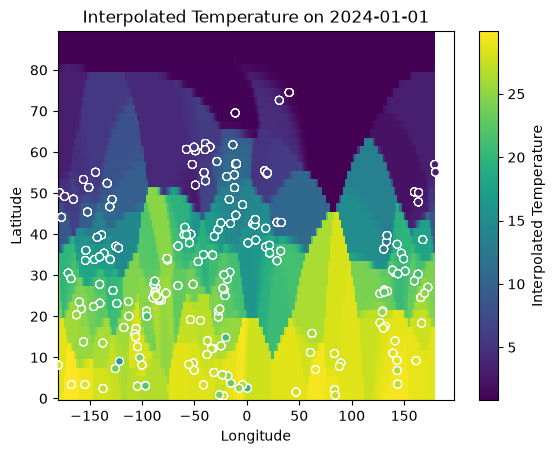

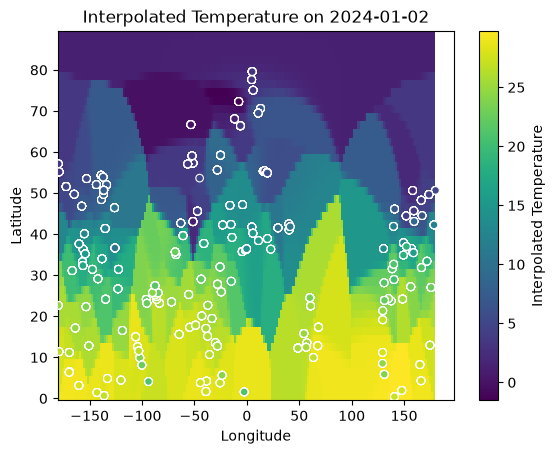

In [7]:
for t_idx, date in enumerate(df['DATE'].unique()):
    tmp_df = df[df['DATE'] == date]
    plt.figure()
    plt.pcolormesh(lons, lats, temp_data[t_idx], shading='auto', cmap='viridis')
    plt.colorbar(label='Interpolated Temperature')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(f'Interpolated Temperature on {date}')
    plt.scatter(tmp_df['LONGITUDE'], tmp_df['LATITUDE'], c=tmp_df['TEMP'], cmap='viridis',
            edgecolors='white', linewidths=0.8, s=30, zorder=5)

### 1st Haversine method

In [8]:
sigma = 200

# Build flat grid
# Flattens the 2D output grid into a 1D list of (lat, lon) tuples
grid_points = [(lat, lon) for lat in lats for lon in lons]
n_grid = len(grid_points)

for t_idx, date in enumerate(times):
    tmp_df = df[df['DATE'] == date.strftime("%Y-%m-%d")]
    # Creates a list of (lat, lon) tuples 
    obs_points = list(zip(tmp_df['LATITUDE'], tmp_df['LONGITUDE']))
    obs_temps = tmp_df['TEMP'].values
    n_obs = len(obs_points)

    # Compute the distance from every obs station to every grid point (an (n_grid × n_obs) matrix) in one call.
    # Compute all obs→grid distances: shape (n_obs * n_grid,)
    # haversine_vector expects two equal-length lists
    obs_repeated = obs_points * n_grid          # each obs point repeated n_grid times
    grid_tiled = [gp for gp in grid_points for _ in range(n_obs)]  # each grid point repeated n_obs times

    distance_km = haversine_vector(
        obs_repeated,
        grid_tiled,
        unit=Unit.KILOMETERS,
    ).reshape(n_grid, n_obs)  # shape: (n_grid, n_obs)

    weights = np.exp(-0.5 * (distance_km / sigma) ** 2)  # (n_grid, n_obs)
    t_weighted = (weights * obs_temps).sum(axis=1)        # (n_grid,)
    sum_weights = weights.sum(axis=1)                     # (n_grid,)

    temp_data[t_idx] = (t_weighted / sum_weights).reshape(len(lats), len(lons))

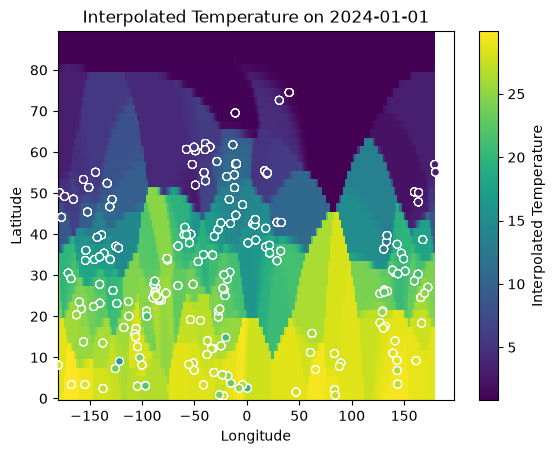

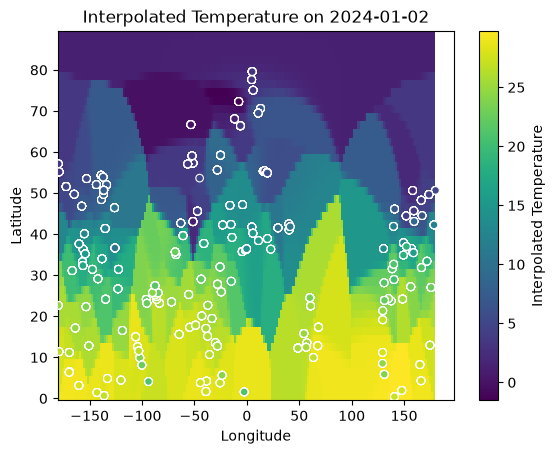

In [9]:
# plot the grid data for each day separately
for t_idx, date in enumerate(df['DATE'].unique()):
    tmp_df = df[df['DATE'] == date]
    plt.figure()
    plt.pcolormesh(lons, lats, temp_data[t_idx], shading='auto', cmap='viridis')
    plt.colorbar(label='Interpolated Temperature')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(f'Interpolated Temperature on {date}')
    plt.scatter(tmp_df['LONGITUDE'], tmp_df['LATITUDE'], c=tmp_df['TEMP'], cmap='viridis',
            edgecolors='white', linewidths=0.8, s=30, zorder=5)

### 2nd Haversine method


In [10]:
sigma = 200
min_weight = 1e-100

for t_idx, date in enumerate(times):
    tmp_df = df[df['DATE'] == date.strftime("%Y-%m-%d")]
    # Creates a list of (lat, lon) tuples 
    obs_lat = tmp_df["LATITUDE"].to_numpy(dtype=float)
    obs_lon = tmp_df["LONGITUDE"].to_numpy(dtype=float)
    obs_points = np.column_stack((obs_lat, obs_lon))  # shape: (n_obs, 2)
        
    # Get positions of observations
    # Pairwise distances in km
    distance_km: np.ndarray = haversine_vector(
        obs_points,
        grid_points,
        unit=Unit.KILOMETERS,
        comb=True,
        check=False,  # faster if your lat/lon are already valid
    )  # shape: (n_lat*n_lon, n_obs)

    # Construct exponential weights, with a minimum for numerical stability
    weights = np.exp(-0.5 * (distance_km / sigma) ** 2).clip(
         min=min_weight
    )  # shape: (n_lat*n_lon, n_obs)
    sum_weights = np.sum(weights, axis=1)  # shape: (n_lat*n_lon,)

    # Apply weights to the data
    # for variable, weighted_array in weighted_data.items():
    unweighted_data = tmp_df['TEMP'].to_numpy(dtype=float)
    temp_data[t_idx] = (
        np.matmul(weights, unweighted_data) / sum_weights
    ).reshape(len(lats), len(lons))  # shape: (n_lat*n_lon,)

print(f"temp_data: {temp_data}")

temp_data: [[[28.67030824 28.67142174 29.52141359 ... 28.67030775 28.67030775
   28.67030775]
  [28.67030777 28.6703674  28.78952706 ... 28.67030775 28.67030775
   28.67030775]
  [28.67030775 28.67031098 28.67725187 ... 28.67030775 28.67030775
   28.67030775]
  ...
  [ 0.80147978  0.80147982  0.80147987 ...  0.80147968  0.80147971
    0.80147974]
  [ 0.80148341  0.8014836   0.80148382 ...  0.80148298  0.8014831
    0.80148324]
  [ 0.80150849  0.80150905  0.80150967 ...  0.80150718  0.80150756
    0.801508  ]]

 [[27.87268731 29.25505688 29.27309199 ... 29.07736407 28.88347908
   27.6905185 ]
  [27.69898268 28.83111459 29.26519028 ... 29.06552674 27.76119774
   27.68851657]
  [27.68963461 27.86130017 29.22743164 ... 28.1354043  27.62692599
   27.68727186]
  ...
  [ 1.27545885  1.27545874  1.27545898 ...  1.27546127  1.27546011
    1.2754593 ]
  [ 1.27565564  1.27565542  1.27565592 ...  1.27566073  1.27565829
    1.2756566 ]
  [ 1.27631406  1.27631374  1.27631446 ...  1.27632127  1.27631

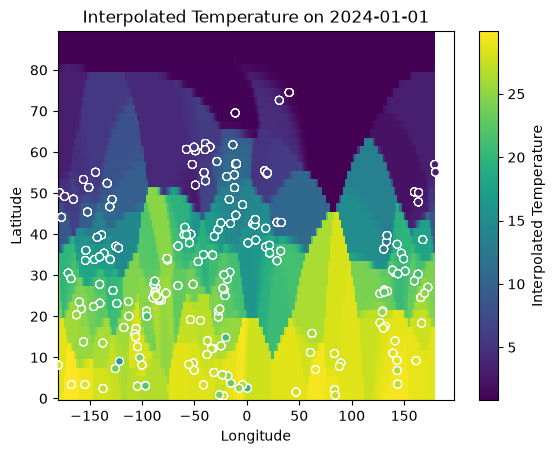

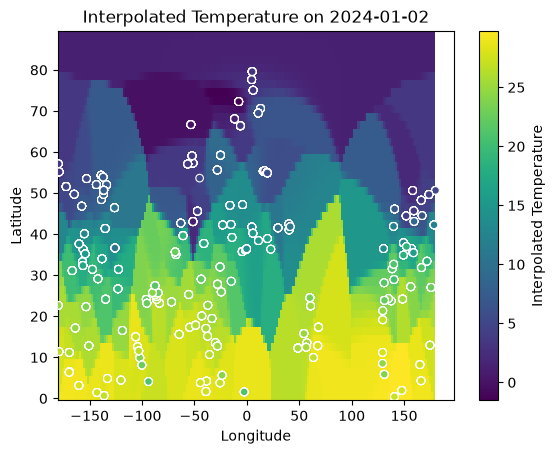

In [11]:
for t_idx, date in enumerate(df['DATE'].unique()):
    tmp_df = df[df['DATE'] == date]
    plt.figure()
    plt.pcolormesh(lons, lats, temp_data[t_idx], shading='auto', cmap='viridis')
    plt.colorbar(label='Interpolated Temperature')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(f'Interpolated Temperature on {date}')
    plt.scatter(tmp_df['LONGITUDE'], tmp_df['LATITUDE'], c=tmp_df['TEMP'], cmap='viridis',
            edgecolors='white', linewidths=0.8, s=30, zorder=5)

### Full argo script

In [12]:
north, west, south, east = 90, -180, 0, 180
grid_resolution_degrees = 2
times = pd.to_datetime(["2024-01-01", "2024-01-02"]).to_pydatetime().tolist()

# Set constants
distance_scale_km = 200
# min_weight = 1e-10

# Construct the grid that we want to project onto
lats = np.arange(
    south + 0.5,
    north + 0.5,
    grid_resolution_degrees,
)
lons = np.arange(
    west + 0.5,
    east + 0.5,
    grid_resolution_degrees,
)

lat_grid, lon_grid = np.meshgrid(lats, lons, indexing="ij")
grid_points = np.column_stack((lat_grid.ravel(), lon_grid.ravel()))

requested_dates = sorted(times)  # sorted(date_group.dates)
weighted_data: dict[str, np.ndarray] = {
    variable: np.full(
        (len(requested_dates), len(lats), len(lons)), np.nan, dtype=float
    )
    for variable in ["TEMP", "PSAL"] 
}
# save the output dataframes to a list
output_dataframes = []

for t_idx, date in enumerate(requested_dates):
    start_time = date
    end_time = date + timedelta(hours=24)
    
    # Extract data for the mixed layer (top 50m), retry if 503 error from erddap
    region = [west, east, south, north, 0, 50, start_time, end_time]
    fetcher = DataFetcher().region(region)
    dataframe = fetcher.to_dataframe()

    # Get positions of observations
    obs_lat = dataframe["LATITUDE"].to_numpy(dtype=float)
    obs_lon = dataframe["LONGITUDE"].to_numpy(dtype=float)
    obs_points = np.column_stack((obs_lat, obs_lon))  # shape: (n_obs, 2)

    # Pairwise distances in km
    distance_km: np.ndarray = haversine_vector(
        obs_points,
        grid_points,
        unit=Unit.KILOMETERS,
        comb=True,
        check=False,  # faster if your lat/lon are already valid
    )  # shape: (n_lat*n_lon, n_obs)

    # Construct exponential weights, with a minimum for numerical stability
    weights = np.exp(-0.5 * (distance_km / distance_scale_km) ** 2) #.clip(
    #     min=min_weight
    # )  # shape: (n_lat*n_lon, n_obs)
    sum_weights = np.sum(weights, axis=1)  # shape: (n_lat*n_lon,)

    # Apply weights to the data
    for variable, weighted_array in weighted_data.items():
        unweighted_data = dataframe[variable].to_numpy(dtype=float)
        weighted_array[t_idx] = (
            np.matmul(weights, unweighted_data) / sum_weights
        ).reshape(len(lats), len(lons))  # shape: (n_lat*n_lon,)
    output_dataframes.append(dataframe)

# Construct an xarray dataset
ds_out = xr.Dataset(
    data_vars={
        variable: (
            ("time", "lat", "lon"),
            data_array,
            {"coordinates": "time lat lon"},
        )
        for variable, data_array in weighted_data.items()
    },
    coords={
        "time": (
            "time",
            np.asarray(requested_dates, dtype="datetime64[ns]"),
            {
                "standard_name": "time",
                "units": "seconds since 1970-01-01 00:00:00",
                "calendar": "standard",
            },
        ),
        "lat": (
            "lat",
            lats,
            {
                "standard_name": "latitude",
                "units": "degrees_north",
            },
        ),
        "lon": (
            "lon",
            lons,
            {
                "standard_name": "longitude",
                "units": "degrees_east",
            },
        ),
    },
)

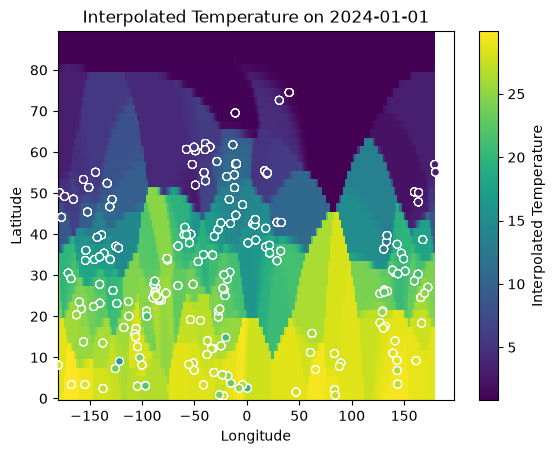

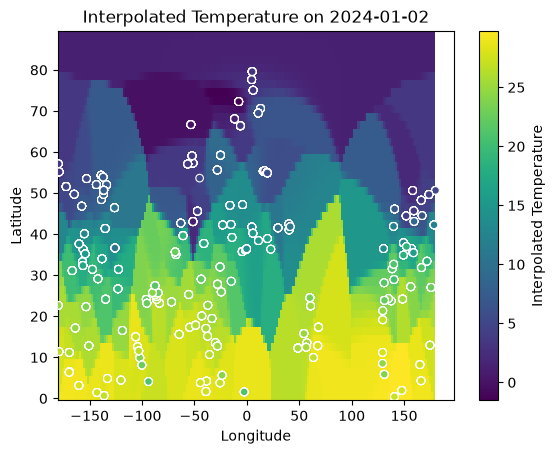

In [13]:
for t_idx, date in enumerate(times):
    dataframe = output_dataframes[t_idx]
    plt.figure()
    plt.pcolormesh(ds_out["lon"], ds_out["lat"], ds_out["TEMP"][t_idx], shading='auto', cmap='viridis')
    plt.colorbar(label='Interpolated Temperature')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(f'Interpolated Temperature on {date.strftime("%Y-%m-%d")}')
    plt.scatter(dataframe['LONGITUDE'], dataframe['LATITUDE'], c=dataframe['TEMP'], cmap='viridis',
        edgecolors='white', linewidths=0.8, s=30, zorder=5)
    


## Comparing xarray files

Note that this is using different parameters as we want finer resolution, shorter time frames etc. for the actual data

### From the argo.py file

In [14]:
north, west, south, east = 90, -180, 20, 180
grid_resolution_degrees = 1
times = pd.to_datetime(["2017-01-18", "2017-01-19"]).to_pydatetime().tolist()

# Set constants
distance_scale_km = 2000
min_weight = 1e-10

# Construct the grid that we want to project onto
lats = np.arange(
    south + 0.5 * grid_resolution_degrees,
    north + 0.5 * grid_resolution_degrees,
    grid_resolution_degrees,
)
lons = np.arange(
    west + 0.5 * grid_resolution_degrees,
    east + 0.5 * grid_resolution_degrees,
    grid_resolution_degrees,
)

lat_grid, lon_grid = np.meshgrid(lats, lons, indexing="ij")
grid_points = np.column_stack((lat_grid.ravel(), lon_grid.ravel()))

requested_dates = sorted(times)  # sorted(date_group.dates)
weighted_data: dict[str, np.ndarray] = {
    variable: np.full(
        (len(requested_dates), len(lats), len(lons)), np.nan, dtype=float
    )
    for variable in ["TEMP", "PSAL"] 
}
# save the output dataframes to a list
output_dataframes = []

for t_idx, date in enumerate(requested_dates):
    start_time = date + timedelta(hours=10)
    end_time = date + timedelta(hours=14) 
    
    # Extract data for the mixed layer (top 50m), retry if 503 error from erddap
    region = [west, east, south, north, 0, 50, start_time, end_time]
    fetcher = DataFetcher().region(region)
    dataframe = fetcher.to_dataframe()

    # Get positions of observations
    obs_lat = dataframe["LATITUDE"].to_numpy(dtype=float)
    obs_lon = dataframe["LONGITUDE"].to_numpy(dtype=float)
    obs_points = np.column_stack((obs_lat, obs_lon))  # shape: (n_obs, 2)

    # Pairwise distances in km
    distance_km: np.ndarray = haversine_vector(
        obs_points,
        grid_points,
        unit=Unit.KILOMETERS,
        comb=True,
        check=False,  # faster if your lat/lon are already valid
    )  # shape: (n_lat*n_lon, n_obs)

    # Construct exponential weights, with a minimum for numerical stability
    weights = np.exp(-0.5 * (distance_km / distance_scale_km) ** 2).clip(
        min=min_weight
    )  # shape: (n_lat*n_lon, n_obs)
    sum_weights = np.sum(weights, axis=1)  # shape: (n_lat*n_lon,)

    # Apply weights to the data
    for variable, weighted_array in weighted_data.items():
        unweighted_data = dataframe[variable].to_numpy(dtype=float)
        weighted_array[t_idx] = (
            np.matmul(weights, unweighted_data) / sum_weights
        ).reshape(len(lats), len(lons))  # shape: (n_lat*n_lon,)
    output_dataframes.append(dataframe)

# Construct an xarray dataset
ds_out = xr.Dataset(
    data_vars={
        variable: (
            ("time", "lat", "lon"),
            data_array,
            {"coordinates": "time lat lon"},
        )
        for variable, data_array in weighted_data.items()
    },
    coords={
        "time": (
            "time",
            np.asarray(requested_dates, dtype="datetime64[ns]"),
            {
                "standard_name": "time",
                "units": "seconds since 1970-01-01 00:00:00",
                "calendar": "standard",
            },
        ),
        "lat": (
            "lat",
            lats,
            {
                "standard_name": "latitude",
                "units": "degrees_north",
            },
        ),
        "lon": (
            "lon",
            lons,
            {
                "standard_name": "longitude",
                "units": "degrees_east",
            },
        ),
    },
)

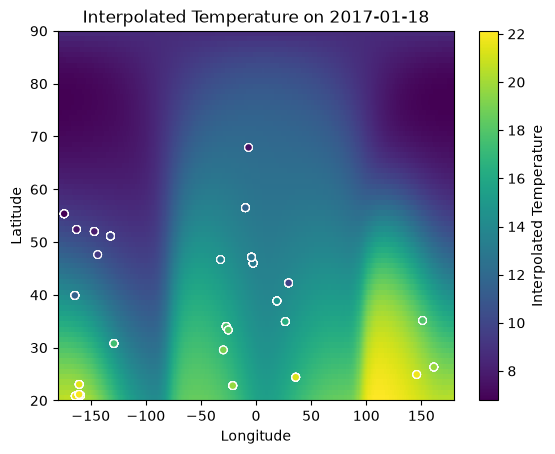

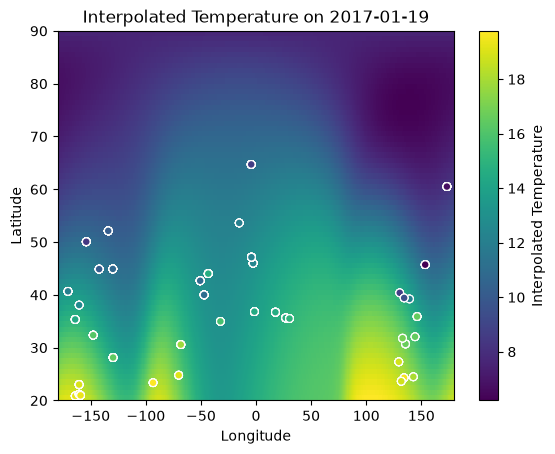

In [15]:
# N.B. These plots only use four hours of data around midday, so they have fewer points than the previous plots (which used the whole day)
for t_idx, date in enumerate(times):
    dataframe = output_dataframes[t_idx]
    plt.figure()
    plt.pcolormesh(ds_out["lon"], ds_out["lat"], ds_out["TEMP"][t_idx], shading='auto', cmap='viridis')
    plt.colorbar(label='Interpolated Temperature')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(f'Interpolated Temperature on {date.strftime("%Y-%m-%d")}')
    plt.scatter(dataframe['LONGITUDE'], dataframe['LATITUDE'], c=dataframe['TEMP'], cmap='viridis',
        edgecolors='white', linewidths=0.8, s=30, zorder=5)
    

### Using downloaded dataset

To run this step you need to have the relevant dataset downloaded. This can be done with the pipeline

`uv run cryocast datasets create --config-name <local_config.yaml>`

Where the local config specifies the base path for saving the data, and the data to download: 

```
defaults:
  - base
  - override /data/datasets: samp_floatnorth_argo_25p0km_2020_2024_24h_v3
  - _self_
  
base_path: <local_path> 
```

In [19]:
base_path = Path("<local_path>")  # set this to your local path
zarr_path = base_path / "samp-floatnorth-argo-25p0km-2020-2024-24h-v3.zarr"

# Try consolidated metadata first (common for produced datasets)
ds_out2 = open_dataset(zarr_path, select = "TEMP")

ds_out2

In [17]:
ds_out2.shape

(1674, 1, 1, 186624)

In [18]:
ds_out2.dates

array(['2020-01-01T12:00:00', '2020-01-02T12:00:00',
       '2020-01-03T12:00:00', ..., '2024-07-29T12:00:00',
       '2024-07-30T12:00:00', '2024-07-31T12:00:00'],
      shape=(1674,), dtype='datetime64[s]')

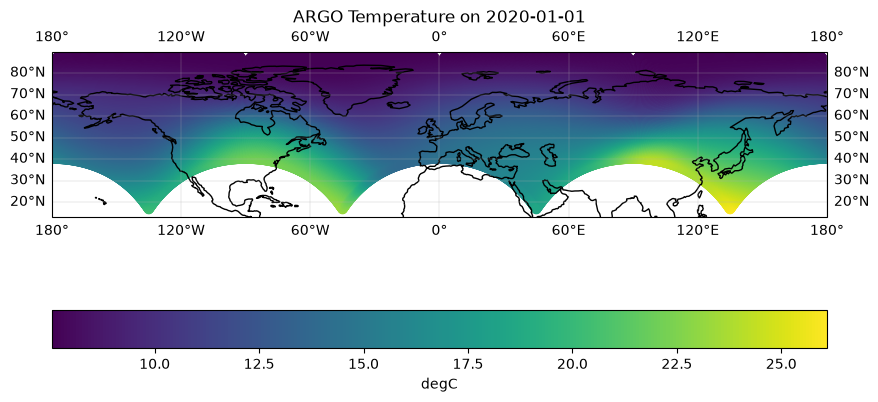

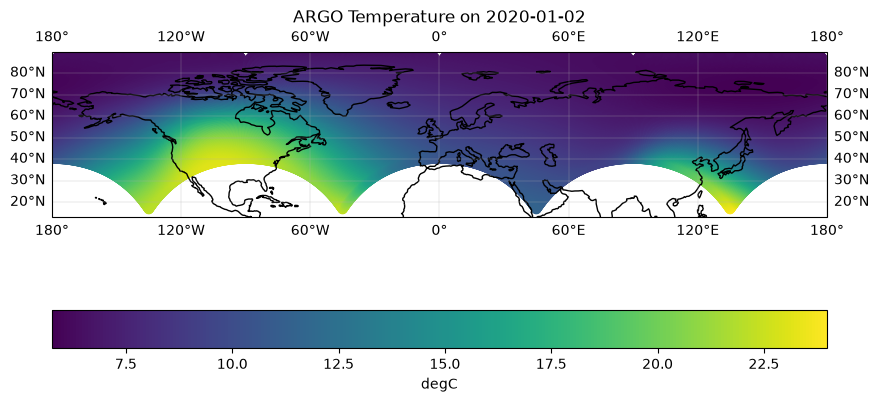

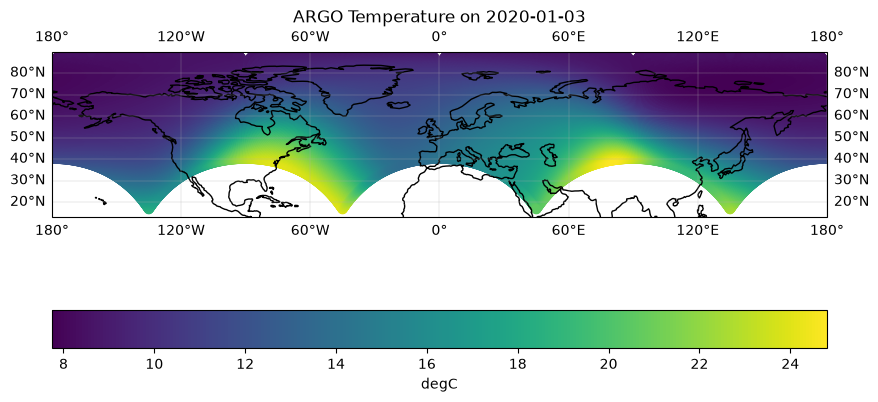

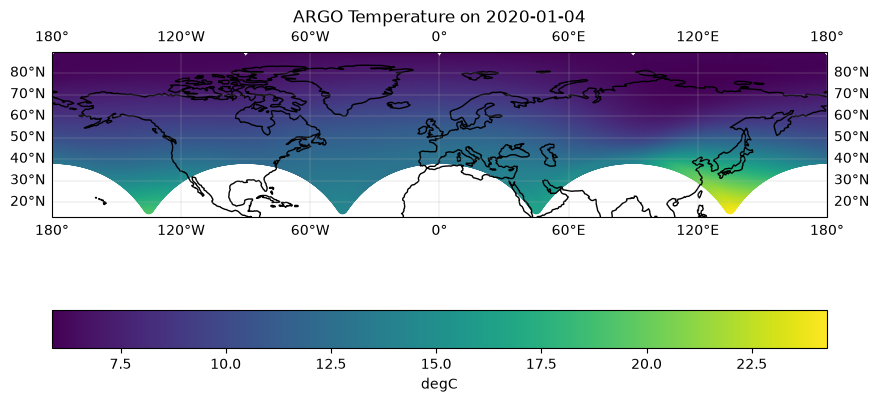

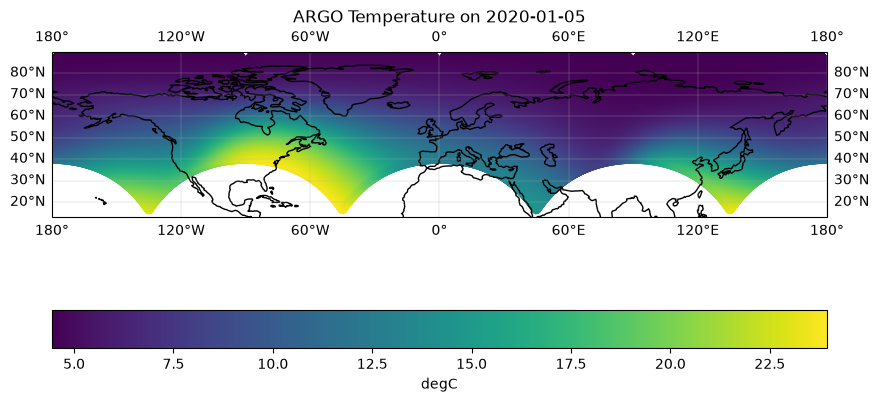

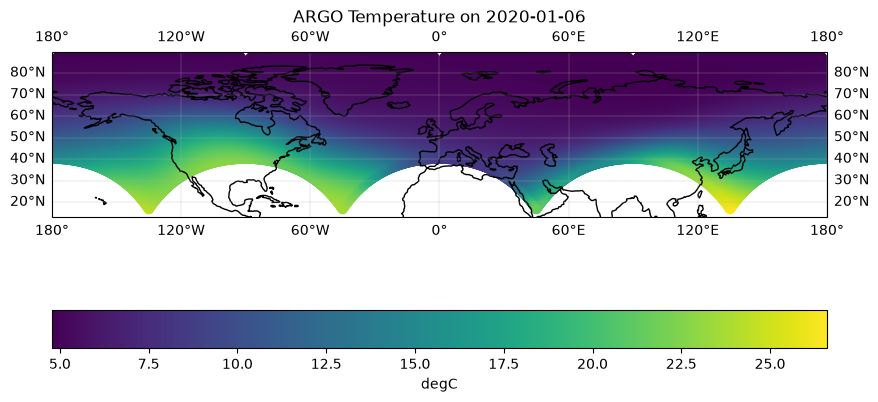

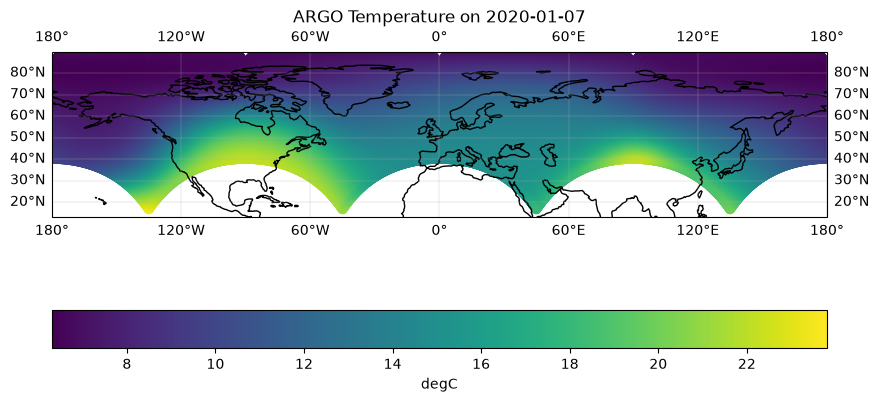

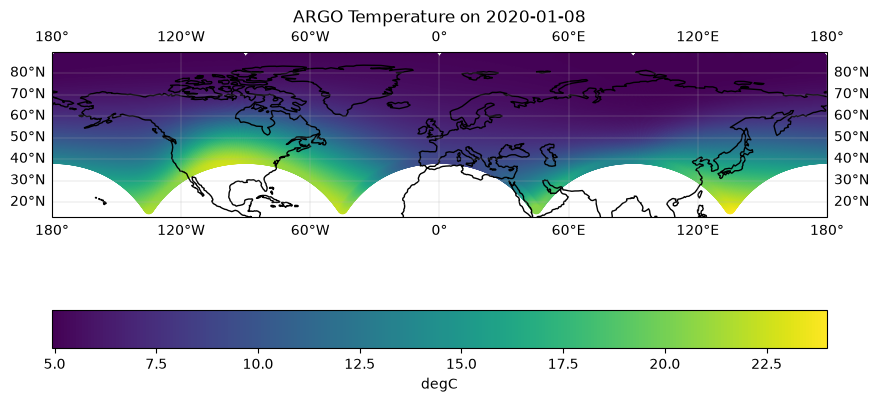

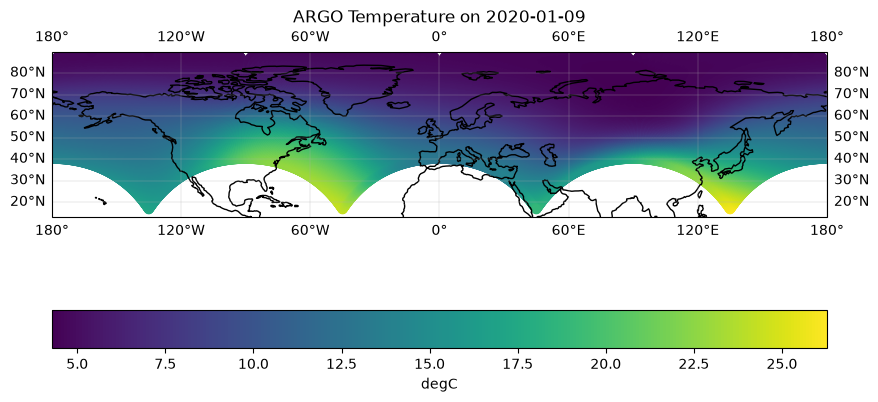

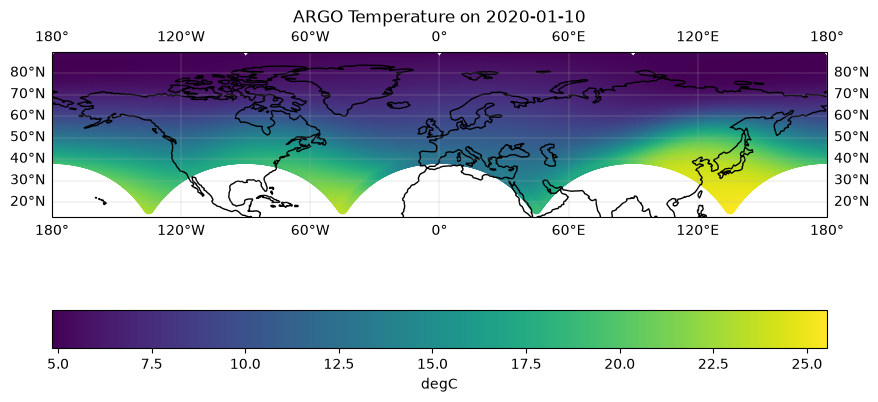

In [19]:
times = pd.to_datetime(ds_out2.dates).to_pydatetime().tolist()
for t_idx, date in enumerate(times[:10]):
    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={"projection": ccrs.PlateCarree()})
    p = ax.scatter(x=ds_out2.longitudes, y=ds_out2.latitudes, c=ds_out2[t_idx, 0, 0, :])
    ax.coastlines()
    ax.gridlines(draw_labels=True, linewidth=0.2)
    plt.colorbar(p, label="degC", orientation="horizontal")
    plt.title(f"ARGO Temperature on {date.strftime('%Y-%m-%d')}")

# Accessing ARGO data

Initially working from the summary sheet: https://argopy.readthedocs.io/en/latest/_static/argopy-cheatsheet.pdf


In [20]:
# Download a dataset based on longitude, latitude, pressure and time range
fetcher = DataFetcher().region([-75, -45, 60, 90, 0, 100, '2026-02', '2026-04'])

In [21]:
fetcher.to_dataframe()

,CYCLE_NUMBER,DATA_MODE,DIRECTION,PLATFORM_NUMBER,POSITION_QC,PRES,PRES_ERROR,PRES_QC,PSAL,PSAL_ERROR,PSAL_QC,TEMP,TEMP_ERROR,TEMP_QC,TIME_QC,LATITUDE,LONGITUDE,TIME
N_POINTS,,,,,,,,,,,,,,,,,,
0,162,R,A,4902684,1,0.440000,NaN,1,34.605999,NaN,1,3.888,NaN,1,1,61.393791,-57.83416,2026-02-02 03:17:00
1,162,R,A,4902684,1,0.570000,NaN,1,34.605000,NaN,1,3.888,NaN,1,1,61.393791,-57.83416,2026-02-02 03:17:00
2,162,R,A,4902684,1,0.690000,NaN,1,34.604000,NaN,1,3.888,NaN,1,1,61.393791,-57.83416,2026-02-02 03:17:00
3,162,R,A,4902684,1,0.820000,NaN,1,34.605000,NaN,1,3.887,NaN,1,1,61.393791,-57.83416,2026-02-02 03:17:00
4,162,R,A,4902684,1,0.920000,NaN,1,34.606998,NaN,1,3.886,NaN,1,1,61.393791,-57.83416,2026-02-02 03:17:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2578,173,R,A,4902684,1,90.989998,NaN,1,34.859001,NaN,1,4.021,NaN,1,1,60.311192,-58.31398,2026-03-31 09:11:00
2579,173,R,A,4902684,1,93.089996,NaN,1,34.859001,NaN,1,4.021,NaN,1,1,60.311192,-58.31398,2026-03-31 09:11:00
2580,173,R,A,4902684,1,95.010002,NaN,1,34.859001,NaN,1,4.020,NaN,1,1,60.311192,-58.31398,2026-03-31 09:11:00


In [22]:
# Alternatively download specific float profiles
fetcher1 = DataFetcher().float([6902746, 6902755])

In [23]:
# Or specific cycles of a given float
fetcher2 = DataFetcher().profile(6902746, [1,12])

In [24]:
# convert to xarray
fetcher.to_xarray()

<xarray.Dataset> Size: 310kB
Dimensions:          (N_POINTS: 2583)
Coordinates:
    LATITUDE         (N_POINTS) float64 21kB 61.39 61.39 61.39 ... 60.31 60.31
    LONGITUDE        (N_POINTS) float64 21kB -57.83 -57.83 ... -58.31 -58.31
    TIME             (N_POINTS) datetime64[ns] 21kB 2026-02-02T03:17:00 ... 2...
  * N_POINTS         (N_POINTS) int64 21kB 0 1 2 3 4 ... 2579 2580 2581 2582
Data variables: (12/15)
    CYCLE_NUMBER     (N_POINTS) int64 21kB 162 162 162 162 ... 173 173 173 173
    DATA_MODE        (N_POINTS) <U1 10kB 'R' 'R' 'R' 'R' 'R' ... 'R' 'R' 'R' 'R'
    DIRECTION        (N_POINTS) <U1 10kB 'A' 'A' 'A' 'A' 'A' ... 'A' 'A' 'A' 'A'
    PLATFORM_NUMBER  (N_POINTS) int64 21kB 4902684 4902684 ... 4902684 4902684
    POSITION_QC      (N_POINTS) int64 21kB 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    PRES             (N_POINTS) float32 10kB 0.44 0.57 0.69 ... 97.01 99.13
    ...               ...
    PSAL_ERROR       (N_POINTS) float32 10kB nan nan nan nan ... nan nan nan nan
    PSAL_QC          (N_POINTS) int64 21kB 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    TEMP             (N_POINTS) float32 10kB 3.888 3.888 3.888 ... 4.018 4.017
    TEMP_ERROR       (N_POINTS) float32 10kB nan nan nan nan ... nan nan nan nan
    TEMP_QC          (N_POINTS) int64 21kB 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    TIME_QC          (N_POINTS) int64 21kB 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
Attributes:
    DATA_ID:              ARGO
    DOI:                  http://doi.org/10.17882/42182
    Fetched_from:         erddap.ifremer.fr
    Fetched_by:           ifenton
    Fetched_date:         2026/10/02
    Fetched_constraints:  [x=-75.00/-45.00; y=60.00/90.00; z=0.0/100.0; t=202...
    Fetched_uri:          https://erddap.ifremer.fr/erddap/tabledap/ArgoFloat...
    Processing_history:   [PRES,TEMP,PSAL] real-time and adjusted/delayed var...

In [25]:
# convert to pandas dataframe
fetcher.to_dataframe()

,CYCLE_NUMBER,DATA_MODE,DIRECTION,PLATFORM_NUMBER,POSITION_QC,PRES,PRES_ERROR,PRES_QC,PSAL,PSAL_ERROR,PSAL_QC,TEMP,TEMP_ERROR,TEMP_QC,TIME_QC,LATITUDE,LONGITUDE,TIME
N_POINTS,,,,,,,,,,,,,,,,,,
0,162,R,A,4902684,1,0.440000,NaN,1,34.605999,NaN,1,3.888,NaN,1,1,61.393791,-57.83416,2026-02-02 03:17:00
1,162,R,A,4902684,1,0.570000,NaN,1,34.605000,NaN,1,3.888,NaN,1,1,61.393791,-57.83416,2026-02-02 03:17:00
2,162,R,A,4902684,1,0.690000,NaN,1,34.604000,NaN,1,3.888,NaN,1,1,61.393791,-57.83416,2026-02-02 03:17:00
3,162,R,A,4902684,1,0.820000,NaN,1,34.605000,NaN,1,3.887,NaN,1,1,61.393791,-57.83416,2026-02-02 03:17:00
4,162,R,A,4902684,1,0.920000,NaN,1,34.606998,NaN,1,3.886,NaN,1,1,61.393791,-57.83416,2026-02-02 03:17:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2578,173,R,A,4902684,1,90.989998,NaN,1,34.859001,NaN,1,4.021,NaN,1,1,60.311192,-58.31398,2026-03-31 09:11:00
2579,173,R,A,4902684,1,93.089996,NaN,1,34.859001,NaN,1,4.021,NaN,1,1,60.311192,-58.31398,2026-03-31 09:11:00
2580,173,R,A,4902684,1,95.010002,NaN,1,34.859001,NaN,1,4.020,NaN,1,1,60.311192,-58.31398,2026-03-31 09:11:00


In [26]:
# look at the data
fetcher.data

<xarray.Dataset> Size: 310kB
Dimensions:          (N_POINTS: 2583)
Coordinates:
    LATITUDE         (N_POINTS) float64 21kB 61.39 61.39 61.39 ... 60.31 60.31
    LONGITUDE        (N_POINTS) float64 21kB -57.83 -57.83 ... -58.31 -58.31
    TIME             (N_POINTS) datetime64[ns] 21kB 2026-02-02T03:17:00 ... 2...
  * N_POINTS         (N_POINTS) int64 21kB 0 1 2 3 4 ... 2579 2580 2581 2582
Data variables: (12/15)
    CYCLE_NUMBER     (N_POINTS) int64 21kB 162 162 162 162 ... 173 173 173 173
    DATA_MODE        (N_POINTS) <U1 10kB 'R' 'R' 'R' 'R' 'R' ... 'R' 'R' 'R' 'R'
    DIRECTION        (N_POINTS) <U1 10kB 'A' 'A' 'A' 'A' 'A' ... 'A' 'A' 'A' 'A'
    PLATFORM_NUMBER  (N_POINTS) int64 21kB 4902684 4902684 ... 4902684 4902684
    POSITION_QC      (N_POINTS) int64 21kB 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    PRES             (N_POINTS) float32 10kB 0.44 0.57 0.69 ... 97.01 99.13
    ...               ...
    PSAL_ERROR       (N_POINTS) float32 10kB nan nan nan nan ... nan nan nan nan
    PSAL_QC          (N_POINTS) int64 21kB 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    TEMP             (N_POINTS) float32 10kB 3.888 3.888 3.888 ... 4.018 4.017
    TEMP_ERROR       (N_POINTS) float32 10kB nan nan nan nan ... nan nan nan nan
    TEMP_QC          (N_POINTS) int64 21kB 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    TIME_QC          (N_POINTS) int64 21kB 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
Attributes:
    DATA_ID:              ARGO
    DOI:                  http://doi.org/10.17882/42182
    Fetched_from:         erddap.ifremer.fr
    Fetched_by:           ifenton
    Fetched_date:         2026/10/02
    Fetched_constraints:  [x=-75.00/-45.00; y=60.00/90.00; z=0.0/100.0; t=202...
    Fetched_uri:          https://erddap.ifremer.fr/erddap/tabledap/ArgoFloat...
    Processing_history:   [PRES,TEMP,PSAL] real-time and adjusted/delayed var...

In [27]:
# data index
fetcher.index

,date,latitude,longitude,wmo,cyc
0,2026-03-26 03:59:22,60.084700,-47.365000,1902109,63
1,2026-03-22 00:57:18,60.010500,-56.890300,1902111,61
2,2026-03-01 12:53:22,60.218429,-49.106407,1902695,90
3,2026-03-10 12:53:23,60.504957,-49.627861,1902695,91
4,2026-03-19 12:55:23,61.823819,-51.585726,1902695,92
5,2026-03-28 12:55:23,61.788333,-52.785089,1902695,93
6,2026-02-06 05:54:00,62.627937,-52.775505,4902439,281
7,2026-02-16 10:14:00,63.313145,-53.946743,4902439,282
8,2026-02-09 05:10:00,60.291245,-53.799129,4902477,240
9,2026-02-19 10:08:00,60.917343,-52.678402,4902477,241


# Setting the user mode

Defaults to `standard`, but can also choose `research` or `expert`

Select with global option setter:
`argopy.set_options(mode='expert')`
Select in a temporary context:
```
with argopy.set_options(mode='expert'):
    DataFetcher().profile(6902746, 34)
```
Select with fetcher options:
`DataFetcher(mode='research').region([-75, -45, 20, 30, 0, 100])`


# Plotting

(<Figure size 900x540 with 1 Axes>,
 <GeoAxes: xlabel='longitude', ylabel='latitude'>)

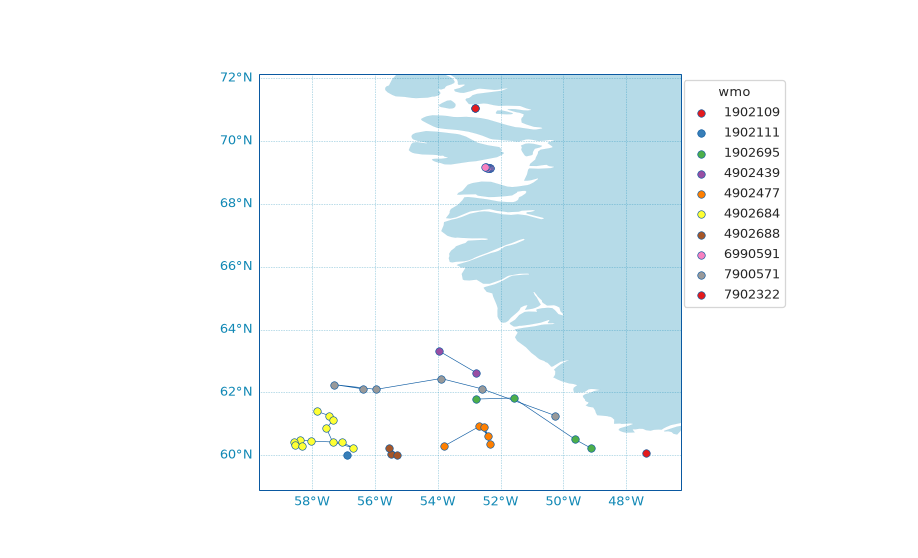

In [28]:
fetcher.plot()

(<Figure size 900x540 with 1 Axes>,
 <GeoAxes: xlabel='longitude', ylabel='latitude'>)

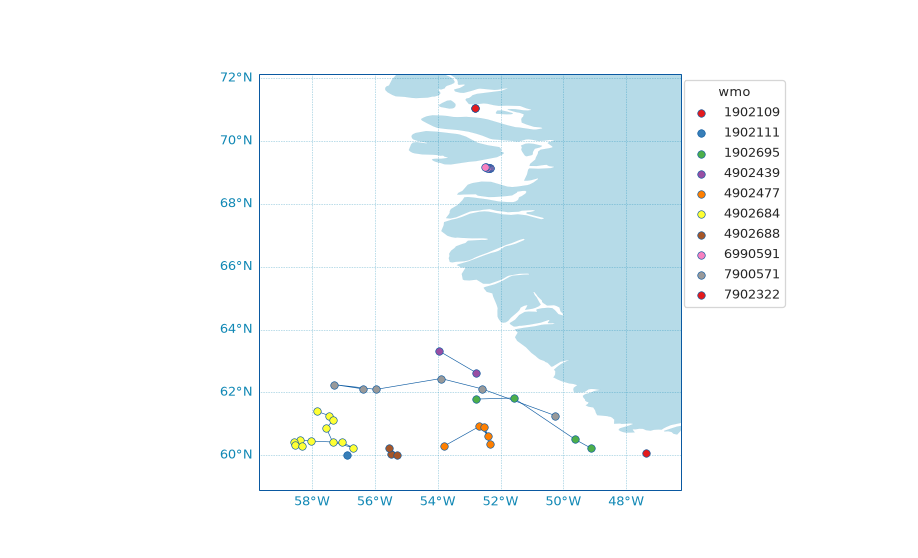

In [29]:
fetcher.plot('trajectory')


(<Figure size 900x540 with 1 Axes>, <Axes: xlabel='Number of profiles'>)

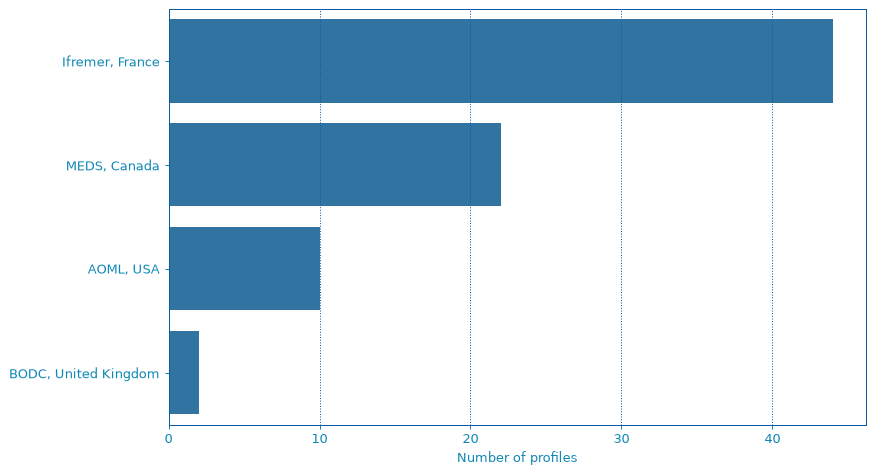

In [30]:
fetcher.plot('dac')


(<Figure size 900x540 with 1 Axes>, <Axes: xlabel='Number of profiles'>)

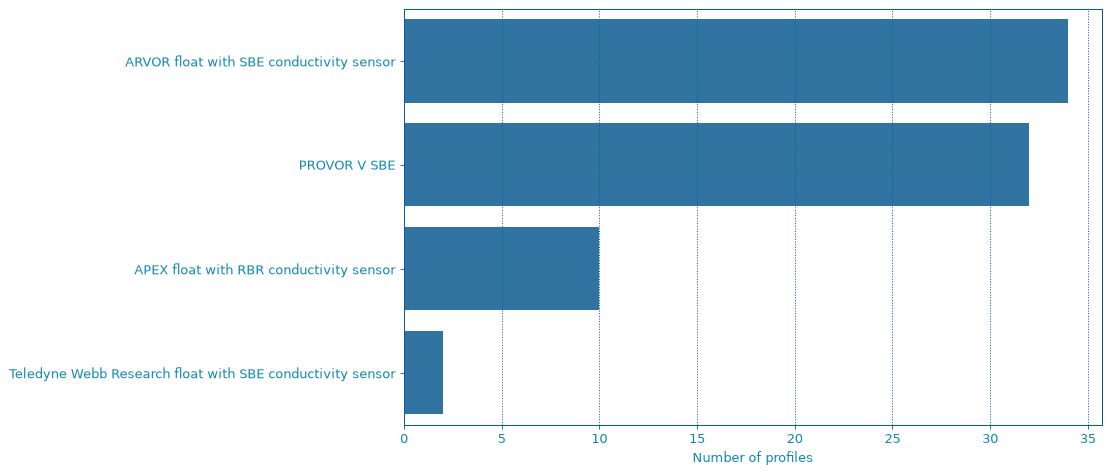

In [31]:
fetcher.plot('profiler')


(<Figure size 900x540 with 2 Axes>,
 <GeoAxes: title={'center': 'Argo float WMO: 6902746'}, xlabel='Longitude of the station, best\nestimate [degree_east]', ylabel='Latitude of the station, best\nestimate [degree_north]'>,
 {'scatter': [<matplotlib.collections.PathCollection at 0x3135ddf10>,
  'cbar': <matplotlib.colorbar.Colorbar at 0x3136e1cd0>,
  'legend': None,
  'traj': [<matplotlib.lines.Line2D at 0x314309910>],
  'ArgoColors': <argopy.plot.argo_colors.ArgoColors at 0x31340cdd0>})

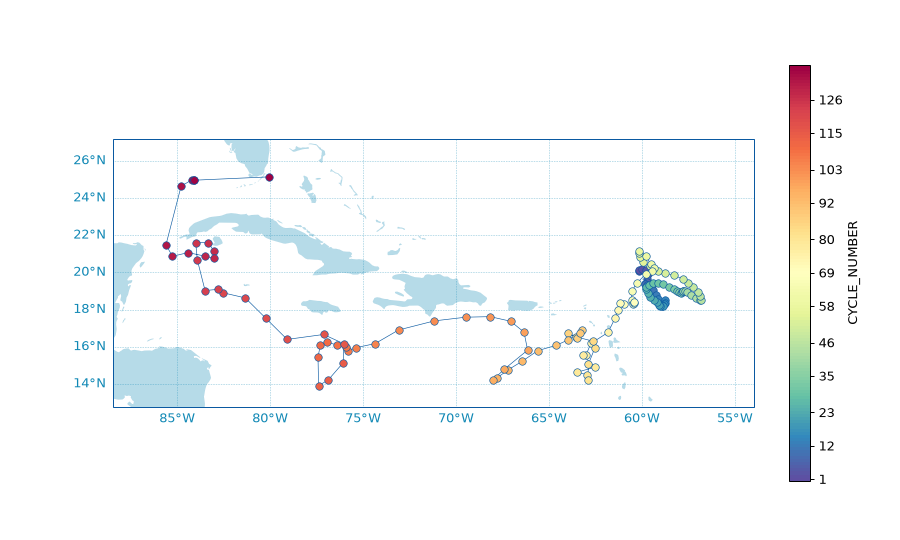

In [ ]:
# ArgoFloat
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None} # fix a bug in the plotting
from argopy import ArgoFloat
af = ArgoFloat(6902746)
af.plot.trajectory()


/Users/ifenton/Documents/Projects/SeaIce/cryocast/.venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2650: RuntimeWarning: invalid value encountered in cast
  output[index] = result


(<Figure size 900x540 with 2 Axes>,
 <GeoAxes: title={'center': 'Argo float WMO: 6902746'}, xlabel='Longitude of the station, best\nestimate [degree_east]', ylabel='Latitude of the station, best\nestimate [degree_north]'>,
 {'scatter': [<matplotlib.collections.PathCollection at 0x31442a450>,
  'cbar': <matplotlib.colorbar.Colorbar at 0x315115710>,
  'legend': None,
  'traj': [<matplotlib.lines.Line2D at 0x3146e9b90>],
  'ArgoColors': <argopy.plot.argo_colors.ArgoColors at 0x31357a790>})

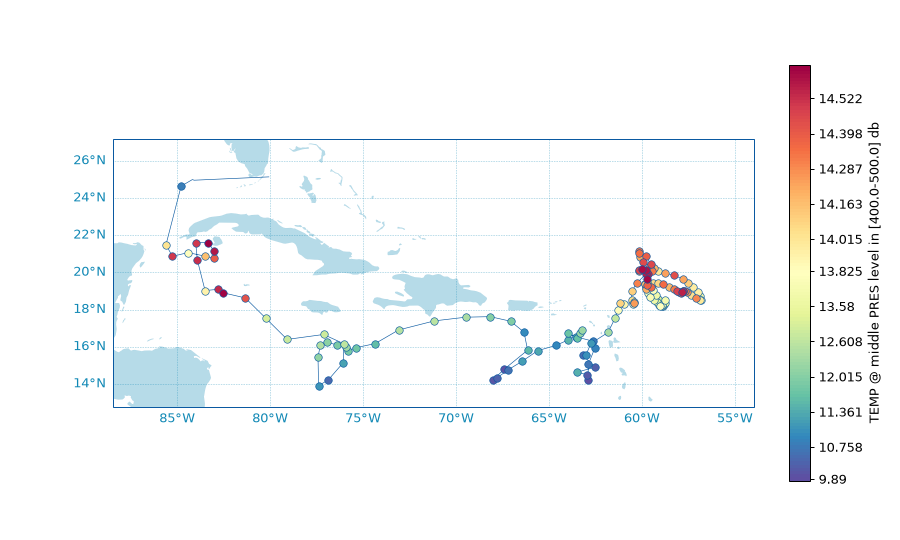

In [36]:
af.plot.map('TEMP', pres=450)


(<Figure size 900x540 with 1 Axes>,
 <GeoAxes: xlabel='Longitude of the station, best\nestimate', ylabel='Latitude of the station, best\nestimate'>,
 {'scatter': [<matplotlib.collections.PathCollection at 0x3146f5910>,
  'cbar': None,
  'legend': <matplotlib.legend.Legend at 0x315150a50>,
  'traj': [<matplotlib.lines.Line2D at 0x315323850>],
  'ArgoColors': <argopy.plot.argo_colors.ArgoColors at 0x31513a810>})

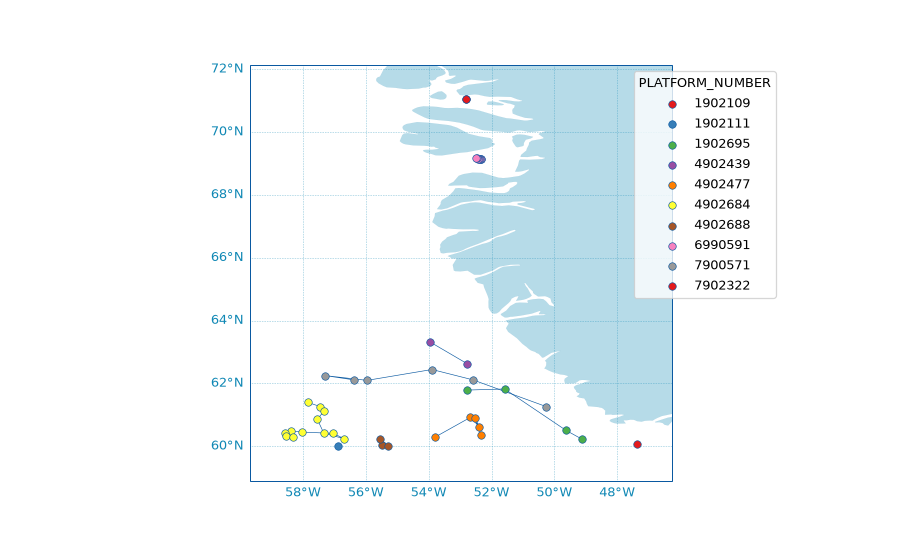

In [37]:
from argopy.plot import scatter_map
ds = fetcher.data.argo.point2profile()
scatter_map(ds)
